In [1]:
import numpy as np
import math
import scipy.constants as const
import matplotlib.pyplot as plt

## Problem 10.3.7 decimal shift map

under: Ch 10 - 1D maps ("difference equations"). How to understand them, sometimes by translating techniques introduced in (continuous) differential equations

$$x_{n+1} = 10 x_n  \mod(1)$$

#### a) Draw the graph of the map

[1.23456789, 0.3456790000000005, 0.4567899999999998, 0.5678999999999998, 0.6790000000000003, 0.79, 0.9000000000000004, 0.0]


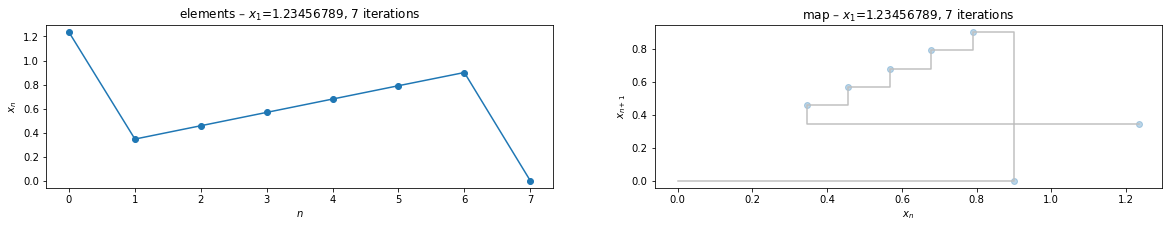

In [2]:
# wrapped into a function
def dec_shift_map(si, stop=None, show=False):
    '''
    si = initial condition
    stop = number of iterations.
        the default value is the number of decimal places as displayed in the input, redefined later inside this function.
        see "Scratch" section of this notebook for explanation.)
        but can be set otherwise.
    show = controls whether or not to print the array of elements generated by the map'''
        
    # compute iteratively
    
    s = [si] # list of values... initialized only with the initial condition
    
        
    if si!=0:
        if stop == None:
            i = 0 # counter
            afters = len(repr(si).split('.')[1]) # get the number of digits after the decimal point in si
            stop = afters - 1 # number of digits of the 2nd element of the map
        
        while len(s) <= stop:
            i+=1
            rem = afters - i
            strip = np.round(s[-1], rem)
            
            s_mod = np.round(10 * abs(strip), rem - 1) # prepare 10x_n, where x_n is the last element in the list...
            s_next = s_mod - math.floor(s_mod) # ... to execute the mod(1) operation on it
            # I assume x_n+1 (x) = x_n+1 (-x)? you can ascribe the negative sign to the integer part anyway...
            s.append(s_next)

    elif si==0:
        while len(s) <= stop:
            s_mod = 10 * abs(s[-1]) 
            s_next = s_mod - math.floor(s_mod)
            s.append(s_next)

    # construct cobweb. i.e. plot the vertex – the intermediate step between each point on the map

    # make the array of points (ordered pairs)
    xn = s[:stop]
    xnext = s[1:]
    pts_map = np.array([xn, xnext])
    pts_map = pts_map.T # T = transpose. so that I get an array of ordered pairs, rather than a pair of arrays.

    # similarly for the vertices
    vertices = np.array([xnext, xnext]).T

    # concatenate both
    cobweb = np.concatenate((pts_map, vertices), axis=1)
    r = cobweb.shape[0]; c = cobweb.shape[1]
    cobweb = cobweb.reshape((2*r, c//2))
    
    # PLOT
    
    fig, ax = plt.subplots(1, 2, figsize=(20, 3))
    # 
    ax[0].plot(np.arange(len(s)), s, marker='o')
    ax[0].set(xlabel='$n$', ylabel='$x_n$', title=f'elements – $x_1$={si}, {stop} iterations')
    
    # points on the map + vertices of the cobweb
    ax[1].plot(cobweb[:,0], cobweb[:,1], color='silver')
    
    # points on the map
    ax[1].scatter(s[:stop], s[1:], marker='o', alpha=0.30)
    # exploit transparency of the visual to distinguish near-overlapping and fixed points from the rest.
    
    ax[1].set(xlabel='$x_n$', ylabel='$x_{n+1}$', title=f'map – $x_1$={si}, {stop} iterations')
    
    if show:
        print(s)
#     else:
#         None

dec_shift_map(si=1.23456789, show=True)

In the left column is a plot of the nth element of each set, given an initial condition.\
The right column of plots is the actual map of the nth element to its next element. 

Notice, from the left column of plots, that the elements of the set goes to zero if you make enough iterations. Can you think why?
What does this operation do?
- discard integer (left of decimal point)
- take digits to the right of the integer
- (x 10) shift decimal point to the right once = shift one digit to the left of the decimal point
- repeat

In this sense, this operation "eats" the number from right to left. (I'll call it a piranha.) Eventually, if you provide a terminating number, the piranha will run out of digits to eat, at which the input is just 0. And the trailing digits of 0 is just 0!

(Caveat in appendix, though.)

#### b) Find all the fixed points

That said, since a fixed point of the map is one where $x_{n+1} = x_n$ for all n, that would mean a number whose decimal digits are all the same.

In other words, this is a number that is non-terminating and with repeating digits. Notable examples are $m + 0.\bar{33} = g / 3$ where $m$ is an integer and $g$ is not a multiple of 3.

WHere else do repeating decimal places occur? Integers – because the digits to the right of the decimal point are all 0. Make the initial integer 0 – then the integer part is like its decimal part, thus **0 is another fixed point**.

Thus, these fixed points should show in the map as a single point. This is why I made the markers of the map less opaque – so that you can easily see a repeating value (a fixed point) overlaying on itself, thus becoming more opaque compared to the rest of the points.

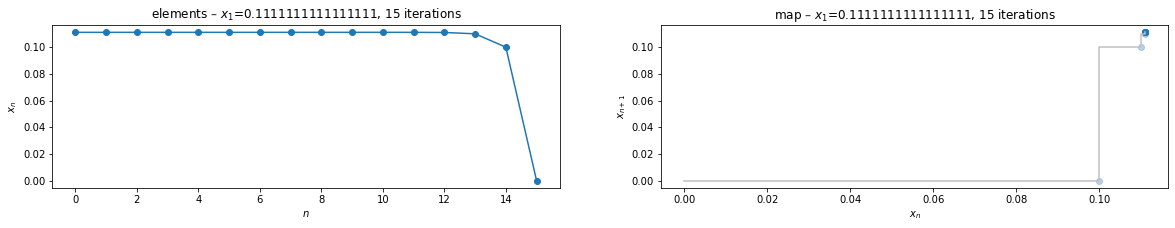

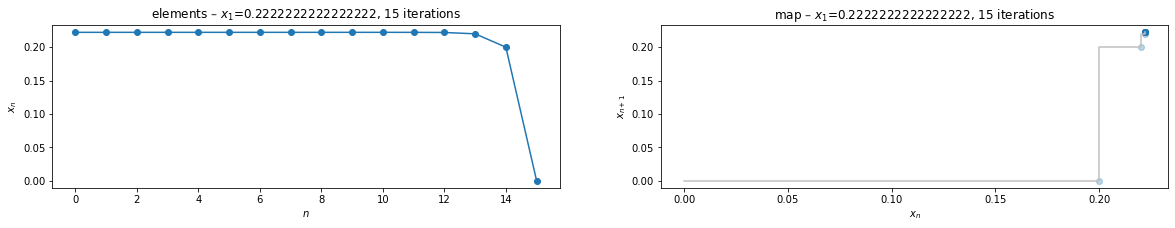

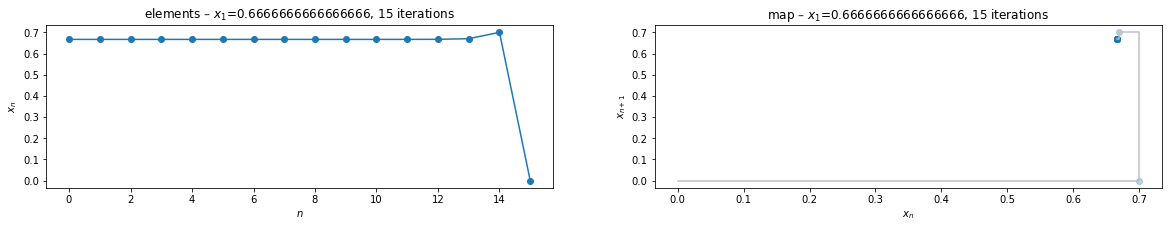

In [3]:
# investigate notable cases; test your guesses of fixed points

# repeating, non-terminating
# a function to generate a number of repeating digits
rep = lambda n: n * 1/9

dec_shift_map(si = rep(n=1))
dec_shift_map(si = rep(n=2))
dec_shift_map(si = rep(n=6))

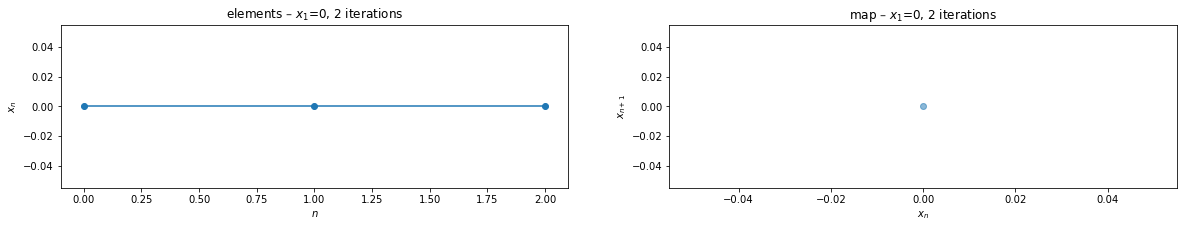

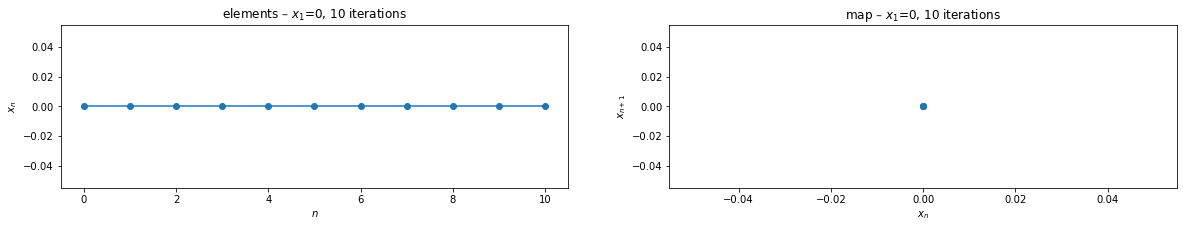

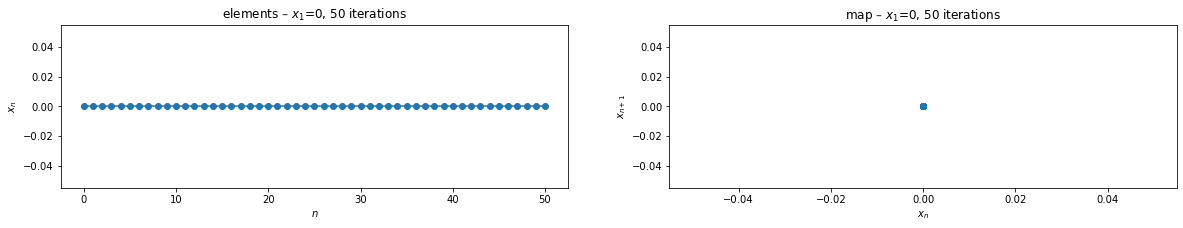

In [4]:
# 0 is a fixed point
dec_shift_map(si=0,stop=2)
dec_shift_map(si=0,stop=10)
dec_shift_map(si=0,stop=50)

#### c) Show that the map has periodic points of all periods but they are unstable.

In other words – show that the map can have period-p cycle and p can be any integer.

This is just saying that 

#### d) Show that the map has infinitely many aperiodic orbits.

Extending the previous venture to irrational numbers shows aperiodic orbits. THis is because, given our digit-eating algorithm, for the number portion to never be the same means that the digits should be nonrepeating.

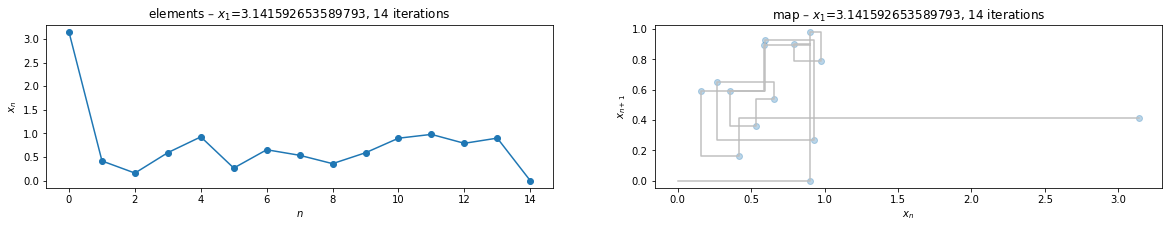

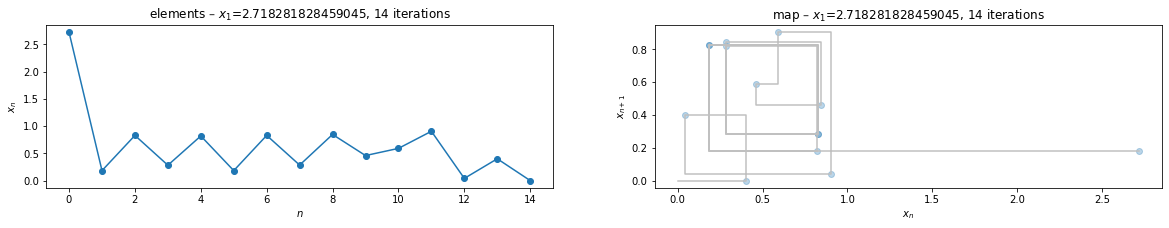

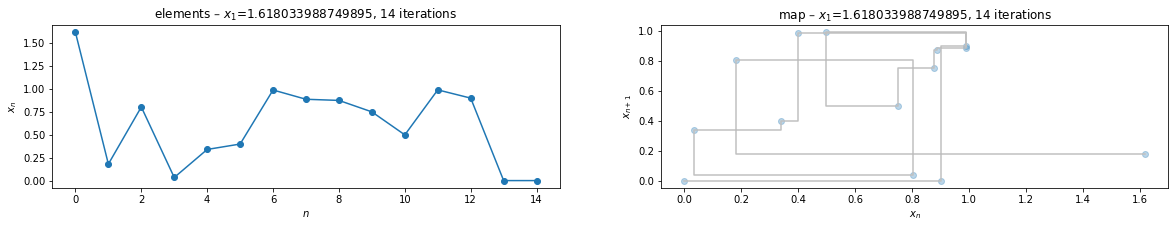

In [5]:
# irrational number – nonrepeating, non-terminating
dec_shift_map(si=math.pi)      # pi
dec_shift_map(si=math.e)       # e
dec_shift_map(si=const.golden) # golden ratio



One can make a number infinitely precise – in other words, keep specifying the digits after the decimal place... to the 400th decimal place, say. As long as you exceed the 

#### e) By considering the rate of separation between two nearby orbits,  show that the map has sensitive dependence on initial conditions.

#### References / Acknowledgements

1. [Floating-Point Arithmetic – Python 3.14.5 documentation](https://docs.python.org/3/tutorial/floatingpoint.html)
2. Many thanks to (Kuya) Lorenzo Joquiño for the discussion and suggestions on the questions and the visualization. :))

---

### Appendix

#### Precision and storing numbers

In [6]:
# what is the actual precision of a decimal number in python? It seems to be more than what is displayed.
s.dtype #'float64'

round(0.1 + 0.1 + 0.1, 1) == 0.3 # the example in [1]
0.1 + 0.1 + 0.1 == 0.3

NameError: name 's' is not defined

More iterations – generating more elements of my map – will turn this into an investigation about computing, because I will bump into decimal places farther down the line, where digits that are supposed to be 0 are not, due to the conversion from binary format that the computer stores the number as.

Because I'm drawing the map with a computer program, the number I type is different from what is displayed – usually 17 digits [1]. Even then, those two numbers are *still* not the "actual" number stored by the computer.

Setting a number of iterations well beyond it does not necessarily put the map to zero. It is only after some number $p$ between 40 and 60 iterations that the map drops to 0. For the nth iteration below p but beyond the last decimal place of the input, the elements of the map seem to vary wildly. This is attributed to the binary expression of the number that, when converted back into the number, is only equal to the number until some nth decimal place – that is usually enough for most users [1].

So reading into the full extent of the number as defined by the computer is going to render the map differently than what I'd get analytically? For the first iterations, no – since there's a lot of decimal places left to eat. To avoid digits imbued by the computer, I must restrict the number of iterations to one less than the number of decimal places of the input.

In [ ]:
dec_shift_map(si=1.2345, stop=10, show=True)
dec_shift_map(si=1.2345, stop=100)
dec_shift_map(si=1.2345, stop=300)

In [ ]:
# scratch – compute the number of decimal places IN INPUT display (NOT as "seen" / stored by computer)
si=1.2345

# get decimal portion
# test = (abs(si) - math.floor(abs(si)))
# print(test)

# then get length of this decimal portion
# len(f'{test}')
# nope, still outputs the precision of the computer

# --- method 2 ---

# len(f'{si}')
dec = f'{si}'.split('.')[1]
# print(dec, len(dec), len(dec) - 1, sep=', ')

# --- method 3: FINAL ---
# what if the input is as a fraction? use `repr` to format its decimal *display* as a string. For example:
print(repr(1/3), repr(1.2345), repr(11/99), sep=', ')
si=1/3
dec = repr(si).split('.')[1]
print(si, dec, len(dec)-1, sep=', ')

---

### Scratch

In [ ]:
# array instead of list
a = np.zeros(shape=1)
a
a = np.concatenate((a, np.array([3])))
len(a)

In [ ]:
# initial draft of algorithm before I wrap it into a function

si = 1.2345 # initial condition

s = [si] # list of map elements... initialized only with the initial condition
# s = np.array([si])

stop = 5 # number of iterations

while len(s) <= stop:
    # access the latest element of the map: s[-1]
    s_mod = 10 * abs(s[-1]) # prepare 10x_n...
    s_next = s_mod - math.floor(s_mod) # ... to execute the mod(1) operation
#     np.concatenate((s, np.array([s_next])))
    s.append(s_next)

s = np.array(s) # convert to array to make it easier to operate on later
print(s)

# construct cobweb.
# construct vertex = intermediate step

# make the array of points (ordered pairs)
xn = s[:stop]
xnext = s[1:]
pts_map = np.array([xn, xnext])
# print(pts_map)
pts_map = pts_map.T#
# pts_map = pts_map.reshape(pts_map.shape[0], pts_map.shape[1], 1) # transpose
# print(pts_map)

# similarly
vertices = np.array([xnext, xnext]).T
# vertices = vertices.reshape(vertices.shape[0], vertices.shape[1], 1)
# print(vertices)

# concatenate both
cobweb = np.concatenate((pts_map, vertices), axis=1)
# print(cobweb)
r = cobweb.shape[0]; c = cobweb.shape[1] // 2
cobweb = cobweb.reshape((2*r, c))
print(cobweb)

# plot

fig, ax = plt.subplots()

# points on the map + vertices of the cobweb
ax.plot(cobweb[:,0], cobweb[:,1], color='silver')
# points on the map
ax.scatter(s[:stop], s[1:], marker='o', alpha=0.30) # exploit transparency of the visual to distinguish near-overlapping and fixed points from the rest.

ax.set(xlabel='$x_n$', ylabel='$x_{n+1}$')

---

In [ ]:
# scratch
# compare to a builtin mod 1 function if there is one
print(math.modf(11.618)) # first element of this tuple...
dec_shift_map(si=1.1618, stop=2, show=True) # vs 2nd element of this function (iteration)

Notice the builtin function adds digits that are not there, vs. my manual programming of `mod(1)` function.

---

In [ ]:
# the example in the problem: 2.63 mod(1) i.e. initial condition = 0.263
dec_shift_map(si=0.263, stop=10)
dec_shift_map(si=0.263, stop=1000)

---

In [ ]:
# scratch
# number of iterations ≤ length of the irrational number encoded in Python, so that I can display its irrational nature.
# because an irrational number is really nonterminating but Python can't store a number that never ends.

len(f'{math.pi}') - 1 # -1 to exclude the decimal point in the character count
# 16

len(f'{math.e}') - 1
# 16 too